> #### Environment Setup
> Copy the following line to the terminal
> ```cmd
> pip install matplotlib seaborn numpy scipy scikit-learn tensorflow yfinance
> ```

# Plan
1. Fetch Data
2. Generate All Candidate Features (technical indicators, returns, ratios, time)
3. Forward Selection — find the best feature subset
4. Data Preparation — selected features, train/test split **before** scaling, RobustScaler
5. Build & Train LSTM — two LSTM layers with Dropout, EarlyStopping
6. Predict & Visualize
7. Evaluate — RMSE, MAE, MAPE

# 0. Setup and Dependencies

In [1]:
%pip install matplotlib seaborn numpy pandas scipy scikit-learn tensorflow yfinance fredapi vaderSentiment google-news-api --quiet

import os, time, itertools, warnings
import numpy  as np
import pandas as pd
warnings.filterwarnings('ignore')

# Deep-learning stack
import tensorflow as tf
from keras.models     import Sequential, Model
from keras.layers     import (LSTM, Dense, Dropout, Input)

from keras.callbacks  import EarlyStopping

# Classical ML
from sklearn.linear_model import LassoCV
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import RobustScaler

# Finance data
import yfinance as yf
from fredapi import Fred

# Sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

os.makedirs('data',   exist_ok=True)
os.makedirs('models', exist_ok=True)
print('✅ All dependencies loaded')

Note: you may need to restart the kernel to use updated packages.
✅ All dependencies loaded


---
# 1. Fetching Stock Data

In [2]:
START_DATE = '2018-01-01'
END_DATE = '2025-12-31'

stock_data = yf.download('AAPL', start=START_DATE, end=END_DATE, multi_level_index=False)
stock_data

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2018-01-02,40.304176,40.313537,39.602258,39.812835,102223600
2018-01-03,40.297161,40.839980,40.233991,40.367354,118071600
2018-01-04,40.484344,40.587293,40.262071,40.369696,89738400
2018-01-05,40.945263,41.031832,40.489016,40.580266,94640000
2018-01-08,40.793182,41.087987,40.694911,40.793182,82271200
...,...,...,...,...,...
2025-12-23,272.105377,272.245261,269.308007,270.586809,29642000
2025-12-24,273.554016,275.172497,271.945536,272.085389,17910600
2025-12-26,273.144409,275.112569,272.604905,273.903708,21521800


---
# 2. Generate All Candidate Features

### 2.0 Configuration

In [3]:
# ─── API Keys ─────────────────────────────────────────────────────────────────
# FRED  : free at https://fred.stlouisfed.org/docs/api/api_key.html
# Alpha Vantage: free at https://www.alphavantage.co/support/#api-key (25 req/day)
FRED_API_KEY     = 'c29c1ffcf50543aaa811b9b3a6a479bd'
ALPHA_VANTAGE_API_KEY = 'DVEJ89KMZD2QR4UW'
# Pull macro data slightly earlier so rolling windows are warm at TRAIN_START
MACRO_START = '2016-01-01'

### 2.1 Technical Features

In [4]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

df = stock_data.copy()

# --- Technical indicators ---
for w in [5, 10, 20, 50]:
    df[f'SMA_{w}']    = df['Close'].rolling(w).mean()
    df[f'EMA_{w}']    = df['Close'].ewm(span=w).mean()
    df[f'Volatility_{w}'] = df['Close'].pct_change().rolling(w).std()

df['RSI_14'] = 100 - 100 / (1 + df['Close'].diff().clip(lower=0).rolling(14).mean() /
                             df['Close'].diff().clip(upper=0).abs().rolling(14).mean())

ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
df['MACD']         = ema12 - ema26
df['MACD_signal']  = df['MACD'].ewm(span=9).mean()
df['MACD_hist']    = df['MACD'] - df['MACD_signal']

sma20 = df['Close'].rolling(20).mean()
std20 = df['Close'].rolling(20).std()
df['BB_upper'] = sma20 + 2 * std20
df['BB_lower'] = sma20 - 2 * std20
df['BB_width'] = (df['BB_upper'] - df['BB_lower']) / sma20

high_low  = df['High'] - df['Low']
high_prev = (df['High'] - df['Close'].shift(1)).abs()
low_prev  = (df['Low']  - df['Close'].shift(1)).abs()
df['ATR_14'] = pd.concat([high_low, high_prev, low_prev], axis=1).max(axis=1).rolling(14).mean()

df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).cumsum()

# --- Returns ---
df['log_return']   = np.log(df['Close'] / df['Close'].shift(1))
df['return_1d']    = df['Close'].pct_change()
df['return_5d']    = df['Close'].pct_change(5)

# --- Price ratios ---
df['high_low_ratio']  = df['High'] / df['Low']
df['close_open_ratio'] = df['Close'] / df['Open']

# --- Time features ---
# Year
year_days = df.index.is_leap_year * 366 + (~df.index.is_leap_year) * 365
df['sin_year'] = np.sin(2 * np.pi * (df.index.dayofyear - 1) / year_days)
df['cos_year'] = np.cos(2 * np.pi * (df.index.dayofyear - 1) / year_days)
df['day_of_week'] = df.index.dayofweek / 6.0

# Week (52 weeks)
df['sin_week'] = np.sin(2 * np.pi * (df.index.isocalendar().week - 1) / 52)
df['cos_week'] = np.cos(2 * np.pi * (df.index.isocalendar().week - 1) / 52)

# Month (12 months)
df['sin_month'] = np.sin(2 * np.pi * (df.index.month - 1) / 12)
df['cos_month'] = np.cos(2 * np.pi * (df.index.month - 1) / 12)

# Quarter (4 quarters)
df['sin_quarter'] = np.sin(2 * np.pi * (df.index.quarter - 1) / 4)
df['cos_quarter'] = np.cos(2 * np.pi * (df.index.quarter - 1) / 4)

# --- Target ---
df['Close_nxt'] = df['Close'].shift(-1)
df = df.dropna()


### 2.2 Macro Feature (Pulled from FRED)
| Series | FRED Code | Why It Helps |
|---|---|---|
| VIX | `VIXCLS` | Market fear gauge — spikes before and during crashes |
| Yield curve (10Y-2Y) | `T10Y2Y` | Inversion reliably precedes recessions |
| Fed Funds Rate | `FEDFUNDS` | Rate hike cycles crush tech/growth stocks |
| CPI (Inflation) | `CPIAUCSL` | High inflation = rate hikes = market pressure |
| Credit spread (BAA-AAA) | computed | Widens before financial stress events |
| M2 Money Supply | `M2SL` | Liquidity proxy — correlated with equity returns |
| Unemployment | `UNRATE` | Lagging but useful for recession regime detection |

In [5]:
def fetch_macro_data(fred_api_key, start_date, end_date):
    """
    Pull key macro series from FRED and combine into a weekly DataFrame.

    All series are resampled to weekly frequency (last value of each week)
    to align with the stock price interval. Forward-fill is used for
    series that report monthly (e.g. CPI, unemployment).

    Parameters
    ----------
    fred_api_key : str  — from https://fred.stlouisfed.org
    start_date   : str  — pull from here (earlier than train start to warm windows)
    end_date     : str  — pull until here

    Returns
    -------
    pd.DataFrame indexed by Date (weekly), columns = macro feature names
    """
    if fred_api_key == 'YOUR_FRED_KEY_HERE':
        print('⚠️  No FRED API key set — returning empty macro frame.')
        print('   Get a free key at: https://fred.stlouisfed.org/docs/api/api_key.html')
        # Return empty DataFrame so the rest of the notebook still runs
        return pd.DataFrame()

    fred = Fred(api_key=fred_api_key)

    # ── Series to pull ────────────────────────────────────────────────────────
    SERIES = {
        'vix'         : 'VIXCLS',    # CBOE Volatility Index (daily → weekly)
        'yield_curve' : 'T10Y2Y',    # 10Y minus 2Y Treasury spread
        'fed_funds'   : 'FEDFUNDS',  # Effective Federal Funds Rate
        'cpi'         : 'CPIAUCSL',  # CPI All Items (monthly)
        'baa_rate'    : 'BAA',       # Moody's BAA corporate bond yield
        'aaa_rate'    : 'AAA',       # Moody's AAA corporate bond yield
        'm2'          : 'M2SL',      # M2 money supply (monthly)
        'unemployment': 'UNRATE',    # Unemployment rate (monthly)
    }

    frames = {}
    for name, code in SERIES.items():
        try:
            s = fred.get_series(code, observation_start=start_date, observation_end=end_date)
            # Resample to weekly, forward-fill gaps (monthly data spans multiple weeks)
            s = s.resample('W').last().ffill()
            frames[name] = s
            print(f'  ✓ {name} ({code}): {len(s)} weekly observations')
        except Exception as e:
            print(f'  ✗ {name} ({code}): {e}')

    macro_df = pd.DataFrame(frames)
    macro_df.index = pd.to_datetime(macro_df.index)

    # ── Derived macro features ────────────────────────────────────────────────
    if 'baa_rate' in macro_df and 'aaa_rate' in macro_df:
        # Credit spread: difference between high-yield (BAA) and investment-grade (AAA)
        # When this widens rapidly, credit markets are under stress — a leading crash signal
        macro_df['credit_spread'] = macro_df['baa_rate'] - macro_df['aaa_rate']

    if 'vix' in macro_df:
        # VIX percentile rank over trailing 52 weeks (puts current fear in context)
        macro_df['vix_percentile'] = macro_df['vix'].rolling(52).rank(pct=True)
        # VIX spike flag: current VIX > 1.5× its 52-week rolling mean
        macro_df['vix_spike']      = (macro_df['vix'] > macro_df['vix'].rolling(52).mean() * 1.5).astype(int)

    if 'yield_curve' in macro_df:
        # Yield curve inversion flag: when 2Y yield > 10Y yield, recession risk is elevated
        # Has preceded every US recession since 1955
        macro_df['yield_inverted'] = (macro_df['yield_curve'] < 0).astype(int)

    if 'cpi' in macro_df:
        # Year-over-year CPI change — captures inflation acceleration/deceleration
        macro_df['cpi_yoy'] = macro_df['cpi'].pct_change(52) * 100  # 52 weeks ≈ 1 year

    if 'm2' in macro_df:
        # M2 growth rate: rapid expansion = liquidity-driven rallies;
        # contraction = liquidity crunch (2022 bear market coincided with M2 contraction)
        macro_df['m2_yoy'] = macro_df['m2'].pct_change(52) * 100

    print(f'\nMacro DataFrame shape: {macro_df.shape}')
    return macro_df


macro_df = fetch_macro_data(FRED_API_KEY, MACRO_START, END_DATE)
if not macro_df.empty:
    macro_df.tail()

  ✓ vix (VIXCLS): 523 weekly observations
  ✓ yield_curve (T10Y2Y): 523 weekly observations
  ✓ fed_funds (FEDFUNDS): 519 weekly observations
  ✓ cpi (CPIAUCSL): 519 weekly observations
  ✓ baa_rate (BAA): 519 weekly observations
  ✓ aaa_rate (AAA): 519 weekly observations
  ✓ m2 (M2SL): 519 weekly observations
  ✓ unemployment (UNRATE): 519 weekly observations

Macro DataFrame shape: (523, 14)


### 2.3 Sentiment Data (from Google RSS and VADER)

In [6]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from google_news_api import GoogleNewsClient
from datetime import date
from dateutil.parser import parse
import yfinance as yf
import time
def fetch_google_news_rss(query='Apple',topic='TECHNOLOGY', start_date=str(date.today), end_date=str(date.today())):
    """
    Fetch latest news from Google News RSS feed.
    This is the main function - it fetches real articles!
    """
    print(f'\n📰 FETCHING GOOGLE NEWS RSS FOR: {query} and {topic}')
    
    analyzer = SentimentIntensityAnalyzer()
    client = GoogleNewsClient(
        language='en',
        country='US',
        requests_per_minute=120,
    )
    records = []
    start_date = str(parse(start_date.strip(), dayfirst=True).date())
    print(start_date)
    end_date = str(parse(end_date.strip(), dayfirst=True).date())
    
    try:
        query_news:list[dict] = client.search(
            query,
            after = start_date,
            before = end_date,
            max_results=10000
        )
        topic_news = client.top_news(topic, max_results = 5)
        world_news = client.top_news(max_results=5)
        for news in query_news:
            try:
                title = news.get('title', '')
                summary = news.get('summary', '')
                published = news.get('published') or news.get('pubDate', '')
            
                # Parse date
                try:
                    pub_date = pd.to_datetime(published)
                except:
                    pub_date = pd.Timestamp.now()
                
                # Score sentiment with VADER
                text = f'{title} {summary}'.strip()
                scores = analyzer.polarity_scores(text)
                
                records.append({
                    'Date': pub_date,
                    'headline': title,
                    'sentiment_mean': scores['compound'],
                    'sentiment_pos': scores['pos'],
                    'sentiment_neg': scores['neg'],
                })
                
            except Exception as e:
                continue
        
        if not records:
            print('⚠️  No valid articles found')
            return pd.DataFrame()
        
        df = pd.DataFrame(records)
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').reset_index(drop=True)
        
        print(f'✅ Processed {len(df)} articles')
        print(f'   Date range: {df["Date"].min().date()} to {df["Date"].max().date()}')
        print(f'   Avg sentiment: {df["sentiment_mean"].mean():+.3f}')
        
        return df
        
    except Exception as e:
        print(f'❌ Error: {e}')
        print('💡 Tip: Google News might be temporarily down. Try again in a few seconds.')
        return pd.DataFrame()


sentiment_df = fetch_google_news_rss(start_date=START_DATE, end_date=END_DATE)


📰 FETCHING GOOGLE NEWS RSS FOR: Apple and TECHNOLOGY
2018-01-01
✅ Processed 100 articles
   Date range: 2018-01-24 to 2025-12-17
   Avg sentiment: +0.309


### Options Data (Historical Time Series)
> **Why Options?**
> - The put/call ratio measures how many put (bearish bet) contracts are being bought relative to call (bullish bet) contracts. A high PCR > 1 means traders are paying to protect against downside — a leading signal for fear and potential reversals.
> - **Implied Volatility (IV)** captures market's expectation of future volatility - often leads price movements
> - **IV Skew** (put IV - call IV) shows demand for downside protection
> 
> **Data Source**: [Alpha Vantage](https://www.alphavantage.co/)
> - Free historical put-call ratio (monthly frequency)
> - Other features from yfinance snapshot
> - Get free API key at https://www.alphavantage.co/support/#api-key (25 requests/day)

In [7]:
def fetch_historical_options_features(ticker, start_date, end_date):
    """
    Fetch historical options data: put_call_ratio from Alpha Vantage (monthly), other features from yfinance snapshot.
    
    Uses Alpha Vantage for historical put-call ratio (monthly frequency to respect free tier limits).
    Other features (IV, volume, OI) are fetched as current snapshot from yfinance.
    
    Parameters
    ----------
    ticker    : str - stock ticker symbol (uppercase)
    start_date : str - start date (YYYY-MM-DD)
    end_date  : str - end date (YYYY-MM-DD)
    
    Returns
    -------
    pd.DataFrame indexed by date with columns: put_call_ratio, implied_vol_call,
    implied_vol_put, iv_skew, call_volume, put_volume, call_oi, put_oi
    """
    import requests
    
    api_key = ALPHA_VANTAGE_API_KEY
    if api_key == 'YOUR_KEY_HERE':
        print('⚠️  No Alpha Vantage API key set — returning empty options frame.')
        print('   Get a free key at: https://www.alphavantage.co/support/#api-key')
        return pd.DataFrame()
    
    # Generate monthly end dates (last day of each month)
    dates = pd.date_range(start=start_date, end=end_date, freq='ME')
    records = []
    
    for date in dates:
        date_str = date.strftime('%Y-%m-%d')
        url = f'https://www.alphavantage.co/query?function=HISTORICAL_PUT_CALL_RATIO&symbol={ticker}&date={date_str}&apikey={api_key}'
        try:
            response = requests.get(url)
            data = response.json()
            pcr = data.get('put_call_ratio_full_chain')
            if pcr:
                records.append({'date': date, 'put_call_ratio': float(pcr)})
            time.sleep(1)  # Respect rate limit (25 req/day)
        except Exception as e:
            print(f'Error fetching for {date_str}: {e}')
    
    options_df = pd.DataFrame(records)
    if options_df.empty:
        return pd.DataFrame()
    
    options_df['date'] = pd.to_datetime(options_df['date'])
    options_df = options_df.set_index('date')
    
    # For other features, use yfinance snapshot
    try:
        t = yf.Ticker(ticker)
        exp = t.options
        if not exp:
            print("No options expirations available")
            return options_df  # Return only PCR data
        
        chain = t.option_chain(exp[0])
        calls = chain.calls
        puts = chain.puts
        
        call_vol = calls['volume'].sum()
        put_vol = puts['volume'].sum()
        call_oi = calls['openInterest'].sum()
        put_oi = puts['openInterest'].sum()
        
        mid = len(calls) // 2
        iv_call = calls['impliedVolatility'].iloc[max(0, mid-3):mid+3].mean()
        iv_put = puts['impliedVolatility'].iloc[max(0, mid-3):mid+3].mean()
        
        # Add these as constant columns
        options_df['implied_vol_call'] = iv_call
        options_df['implied_vol_put'] = iv_put
        options_df['iv_skew'] = iv_put - iv_call
        options_df['call_volume'] = call_vol
        options_df['put_volume'] = put_vol
        options_df['call_oi'] = call_oi
        options_df['put_oi'] = put_oi
        
    except Exception as e:
        print(f'Error fetching yfinance data: {e}')
    
    return options_df

options_df = fetch_historical_options_features('AAPL', START_DATE, END_DATE)

In [8]:
macro_df.to_csv('data/macro_data.csv')
sentiment_df.to_csv('data/sentiment.csv')
options_df.to_csv('data/options.csv')
df.to_csv('data/stock_data_AAPL.csv')

## Data Pre-Processing

### Merge and Clean Data

In [9]:
"""
    Properly merge all data sources with aligned dates.

    ==========
    DATAFRAMES
    ==========
    df : pd.DataFrame
        Daily stock technical indicators (index: Date)
    df_macro : pd.DataFrame
        Weekly macro data (index: Date)
    df_sentiment : pd.DataFrame
        Weekly sentiment data (index: Date)
    df_options : pd.DataFrame
        Options data (index: Date)
"""

# Step 1: Ensure all indices are datetime
df.index = pd.to_datetime(df.index)
macro_df.index = pd.to_datetime(macro_df.index)
sentiment_df.index = pd.to_datetime(sentiment_df.index)
options_df.index = pd.to_datetime(options_df.index)

# Step 2: Forward-fill weekly/monthly data to daily frequency
macro_daily = macro_df.reindex(df.index, method='ffill')
sentiment_daily = sentiment_df.reindex(df.index, method='ffill')
options_daily = options_df.reindex(df.index, method='ffill')

# Step 3: Join everything
df_merged = df.copy()
df_merged = df_merged.join([macro_daily, sentiment_daily, options_daily], how='left')

# Step 4: Handle missing values
# Drop rows where critical data is missing
df_merged = df_merged.dropna()
df = df_merged.copy()

print(f"Final merged shape: {df.shape}", df.info())
print(f"Columns: {df.columns.tolist()}")

<class 'pandas.DataFrame'>
DatetimeIndex: 1949 entries, 2018-03-15 to 2025-12-12
Data columns (total 68 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Close             1949 non-null   float64       
 1   High              1949 non-null   float64       
 2   Low               1949 non-null   float64       
 3   Open              1949 non-null   float64       
 4   Volume            1949 non-null   int64         
 5   SMA_5             1949 non-null   float64       
 6   EMA_5             1949 non-null   float64       
 7   Volatility_5      1949 non-null   float64       
 8   SMA_10            1949 non-null   float64       
 9   EMA_10            1949 non-null   float64       
 10  Volatility_10     1949 non-null   float64       
 11  SMA_20            1949 non-null   float64       
 12  EMA_20            1949 non-null   float64       
 13  Volatility_20     1949 non-null   float64       
 14  SMA_50           

In [10]:
'''Download the into csv'''
df.to_csv('data/stock_data_AAPL_final.csv')

---
# 3. Feature Selection
Pearson Correlation Filtering and LASSO

In [11]:
df = pd.read_csv('data/stock_data_AAPL_final.csv')

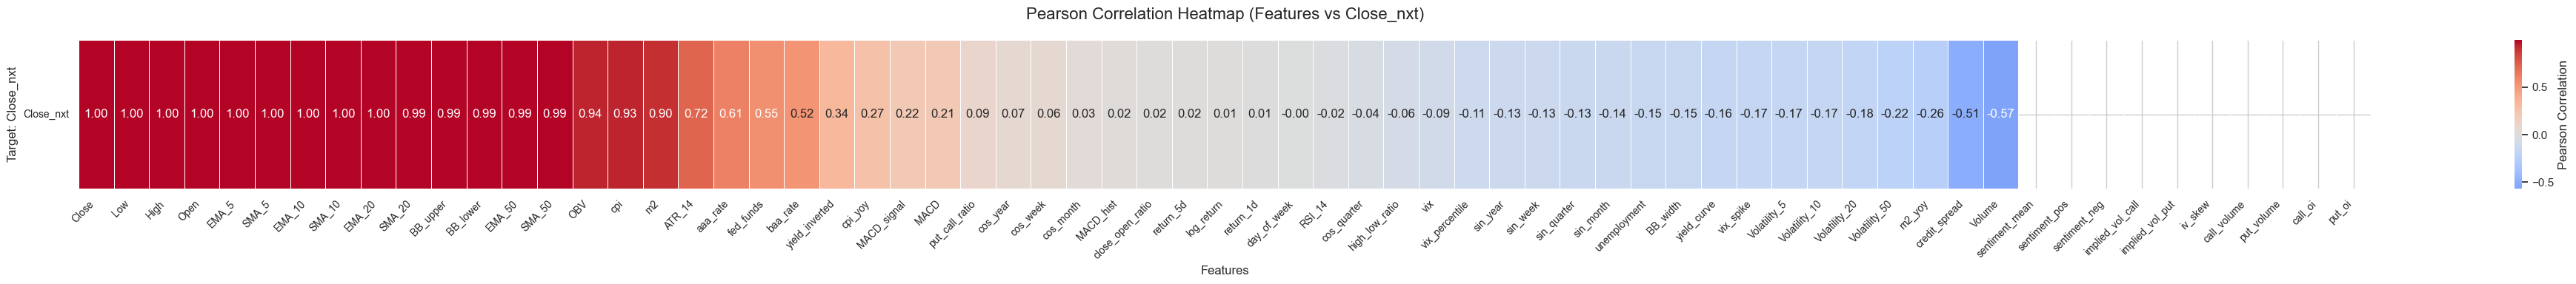


Top 20 Features Correlated with Close_nxt:
           Close_nxt
Close       0.999171
Low         0.998947
High        0.998945
Open        0.998635
EMA_5       0.998522
SMA_5       0.998147
EMA_10      0.997656
SMA_10      0.996965
EMA_20      0.995997
SMA_20      0.994858
BB_upper    0.993200
BB_lower    0.992981
EMA_50      0.991280
SMA_50      0.988291
OBV         0.941004
cpi         0.934296
m2          0.901131
ATR_14      0.724349
aaa_rate    0.609810
fed_funds   0.551067


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# -------- PEARSON CORRELATION VISUALIZATION -------
target_col = ['Close_nxt']

# Select only numeric columns (exclude Date, headline, and any other non-numeric)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in target_col]

# Compute correlations with the target
corr_matrix = df[feature_cols + target_col].corr(method='pearson')

# Extract correlations with target, sort descending
target_corr = corr_matrix[target_col].drop(target_col)
target_corr_sorted = target_corr.sort_values(by=target_col[0], ascending=False)

# Transpose for horizontal heatmap
target_corr_sorted = target_corr_sorted.transpose()

# Plot
plt.figure(figsize=(40, 4))
sns.heatmap(target_corr_sorted, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation'})
plt.title("Pearson Correlation Heatmap (Features vs Close_nxt)", fontsize=16, pad=20)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Target: Close_nxt", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Optional: Print top 20 most correlated features
print("\nTop 20 Features Correlated with Close_nxt:")
print(target_corr[target_col].sort_values(by=target_col[0], ascending=False).head(20))

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import RobustScaler

# Prepare data (using only features, not target)
X = df[list(feature_cols)].values
y = df[target_col].values

# Scale features (separate scaler for train/test)
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# ============ Feature SELECTION ======================

# Tune and train a simple LASSO model _________________

lasso = LassoCV(
    alphas=np.logspace(-4, 4, 100),
    max_iter=100000,
    tol=1e-3,                               # Loosen tolerance
    cv=5,
)
lasso.fit(X_scaled, y.ravel())

lasso_selector = SelectFromModel(lasso, prefit=True)
lasso_mask = lasso_selector.get_support()
print('Lasso Selected: ', lasso_mask.sum())

# Get selected features (non-zero coefficients)
selected_mask = lasso.coef_ != 0
selected_features = np.array(list(feature_cols))[selected_mask].tolist()

print(f'LASSO selected {len(selected_features)} features:')
print(pd.DataFrame(selected_features))

(506, 31) (506, 1)
Lasso Selected:  12
LASSO selected 12 features:
                0
0          RSI_14
1     MACD_signal
2   Volatility_20
3          EMA_10
4             OBV
5          Volume
6           Close
7     cos_quarter
8          ATR_14
9        BB_width
10           MACD
11    sin_quarter


---
# 4. Data Preparation (using selected features)
Split **before** scaling to prevent data leakage. Use separate scalers for input features and the target column.

In [ ]:
from sklearn.preprocessing import RobustScaler
LOOKBACK = 60
TRAIN_RATIO = 0.8
SEL_EPOCHS = 50
SEL_PATIENCE = 8

feature_cols = selected_features          # from forward selection above

split_idx = int(len(df) * TRAIN_RATIO)

df_train = df[:split_idx]
df_test = df[split_idx:]

train_features_raw = df_train[feature_cols]
test_features_raw = df_test[feature_cols]
train_target = df_train[target_col]
test_target = df_test[target_col] 

scaler = RobustScaler()

train_features = scaler.fit_transform(train_features_raw)
test_features  = scaler.transform(test_features_raw)

print(f'Feature columns ({len(feature_cols)}): {feature_cols}')
print(f'Train: {train_features.shape}  Test: {test_features.shape}')

Feature columns (12): ['RSI_14', 'MACD_signal', 'Volatility_20', 'EMA_10', 'OBV', 'Volume', 'Close', 'cos_quarter', 'ATR_14', 'BB_width', 'MACD', 'sin_quarter']
Train: (2024, 12)  Test: (507, 12)


In [ ]:
def create_sequences(features, target, lookback):
    X, y = [], []
    for i in range(lookback, len(features)):
        X.append(features[i - lookback:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

# Create sequences from train (keep normal approach)
X_train, y_train = create_sequences(train_features, train_target, LOOKBACK)

# For test, manually create without padding bias
X_test, y_test = [], []
for i in range(LOOKBACK, len(test_features)):
    X_test.append(test_features[i - LOOKBACK:i])
    y_test.append(test_target[i])
X_test, y_test = np.array(X_test), np.array(y_test)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  y_test : {y_test.shape}')

X_train: (1964, 60, 12)  y_train: (1964,)
X_test : (507, 60, 12)  y_test : (507,)


---
# 5. Building and Training LSTM

In [36]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping

model = Sequential([
    Input(shape=(LOOKBACK, X_train.shape[2])),
    LSTM(100, return_sequences=True),
    Dropout(0.2),
    LSTM(100, return_sequences=False),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 100)        │        45,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 125,701 (491.02 KB)

 Trainable params: 125,701 (491.02 KB)

 Non-trainable params: 0 (0.00 B)

In [37]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 9s 77ms/step - loss: 0.0234 - mae: 0.1015 - val_loss: 0.0183 - val_mae: 0.1079
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0053 - mae: 0.0555 - val_loss: 0.0129 - val_mae: 0.0946
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 0.0048 - mae: 0.0525 - val_loss: 0.0076 - val_mae: 0.0672
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 69ms/step - loss: 0.0039 - mae: 0.0471 - val_loss: 0.0063 - val_mae: 0.0624
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 69ms/step - loss: 0.0037 - mae: 0.0459 - val_loss: 0.0047 - val_mae: 0.0542
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - loss: 0.0033 - mae: 0.0446 - val_loss: 0.0058 - val_mae: 0.0578
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - loss: 0.0033 - mae: 0.0434 - val_loss: 0.0055 - val_mae: 0.0574
Epoch 8/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 7s 97ms/step - loss: 0.0031 - mae: 0.0421 - val_loss: 0.0073 - val_mae: 0.0676
Epoch 9/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - lo

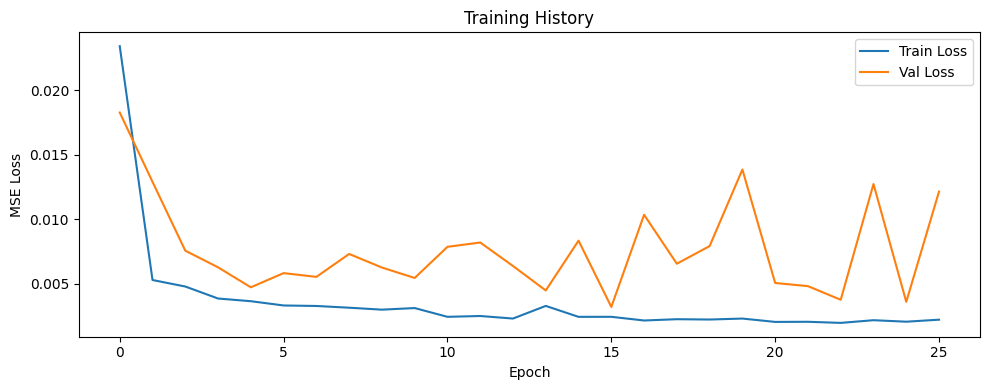

In [38]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

---
# 6. Making Predictions

In [39]:
pred_scaled = model.predict(X_test)

prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

print(f'Predictions shape: {prediction.shape}')
print(f'Actuals shape     : {y_test_actual.shape}')

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
Predictions shape: (507, 1)
Actuals shape     : (507, 1)


---
# 7. Visualisation

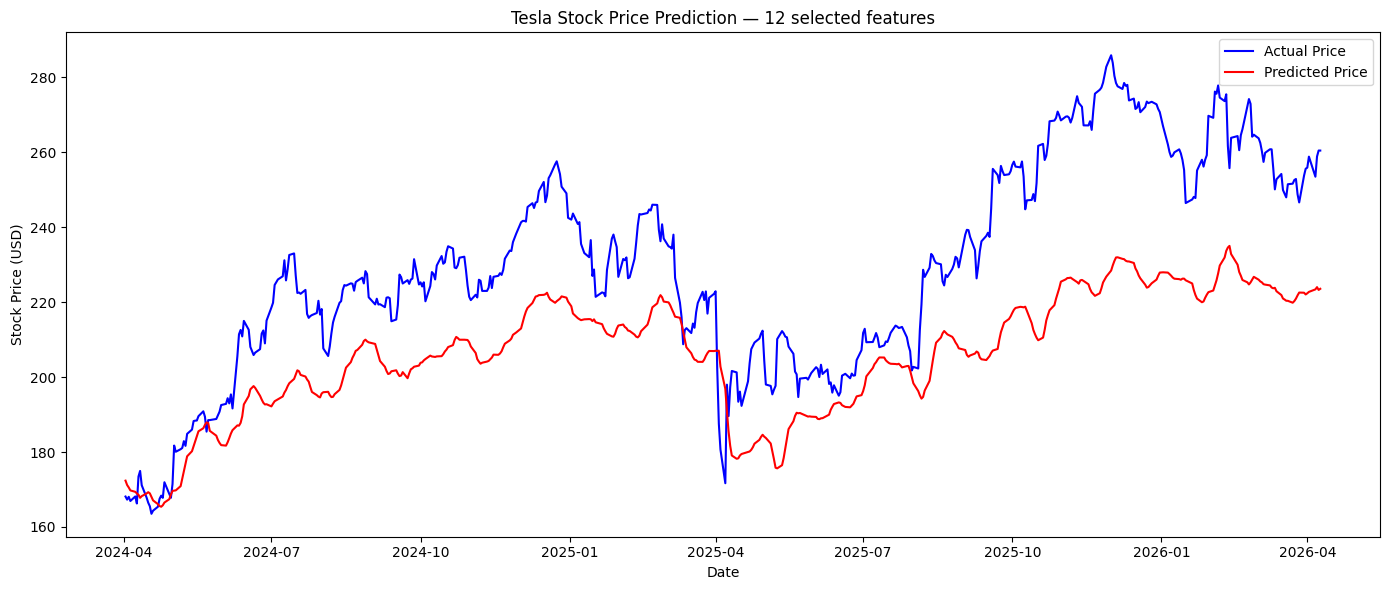

In [41]:
test_dates = df.index[split_idx:]

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual.flatten(), label='Actual Price', color='blue')
plt.plot(test_dates, prediction.flatten(), label='Predicted Price', color='red')
plt.title(f'Tesla Stock Price Prediction — {len(selected_features)} selected features')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

---
# 8. Model Evaluation

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

print('=' * 55)
print(f'LSTM with Forward-Selected Features ({len(feature_cols)})')
print(f'Features: {feature_cols}')
print('=' * 55)
print(f'  MSE  : {mse:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%')
print('=' * 55)

LSTM with Forward-Selected Features (12)
Features: ['RSI_14', 'MACD_signal', 'Volatility_20', 'EMA_10', 'OBV', 'Volume', 'Close', 'cos_quarter', 'ATR_14', 'BB_width', 'MACD', 'sin_quarter']
  MSE  : 731.8476
  RMSE : 27.0527
  MAE  : 23.4953
  MAPE : 9.78%


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


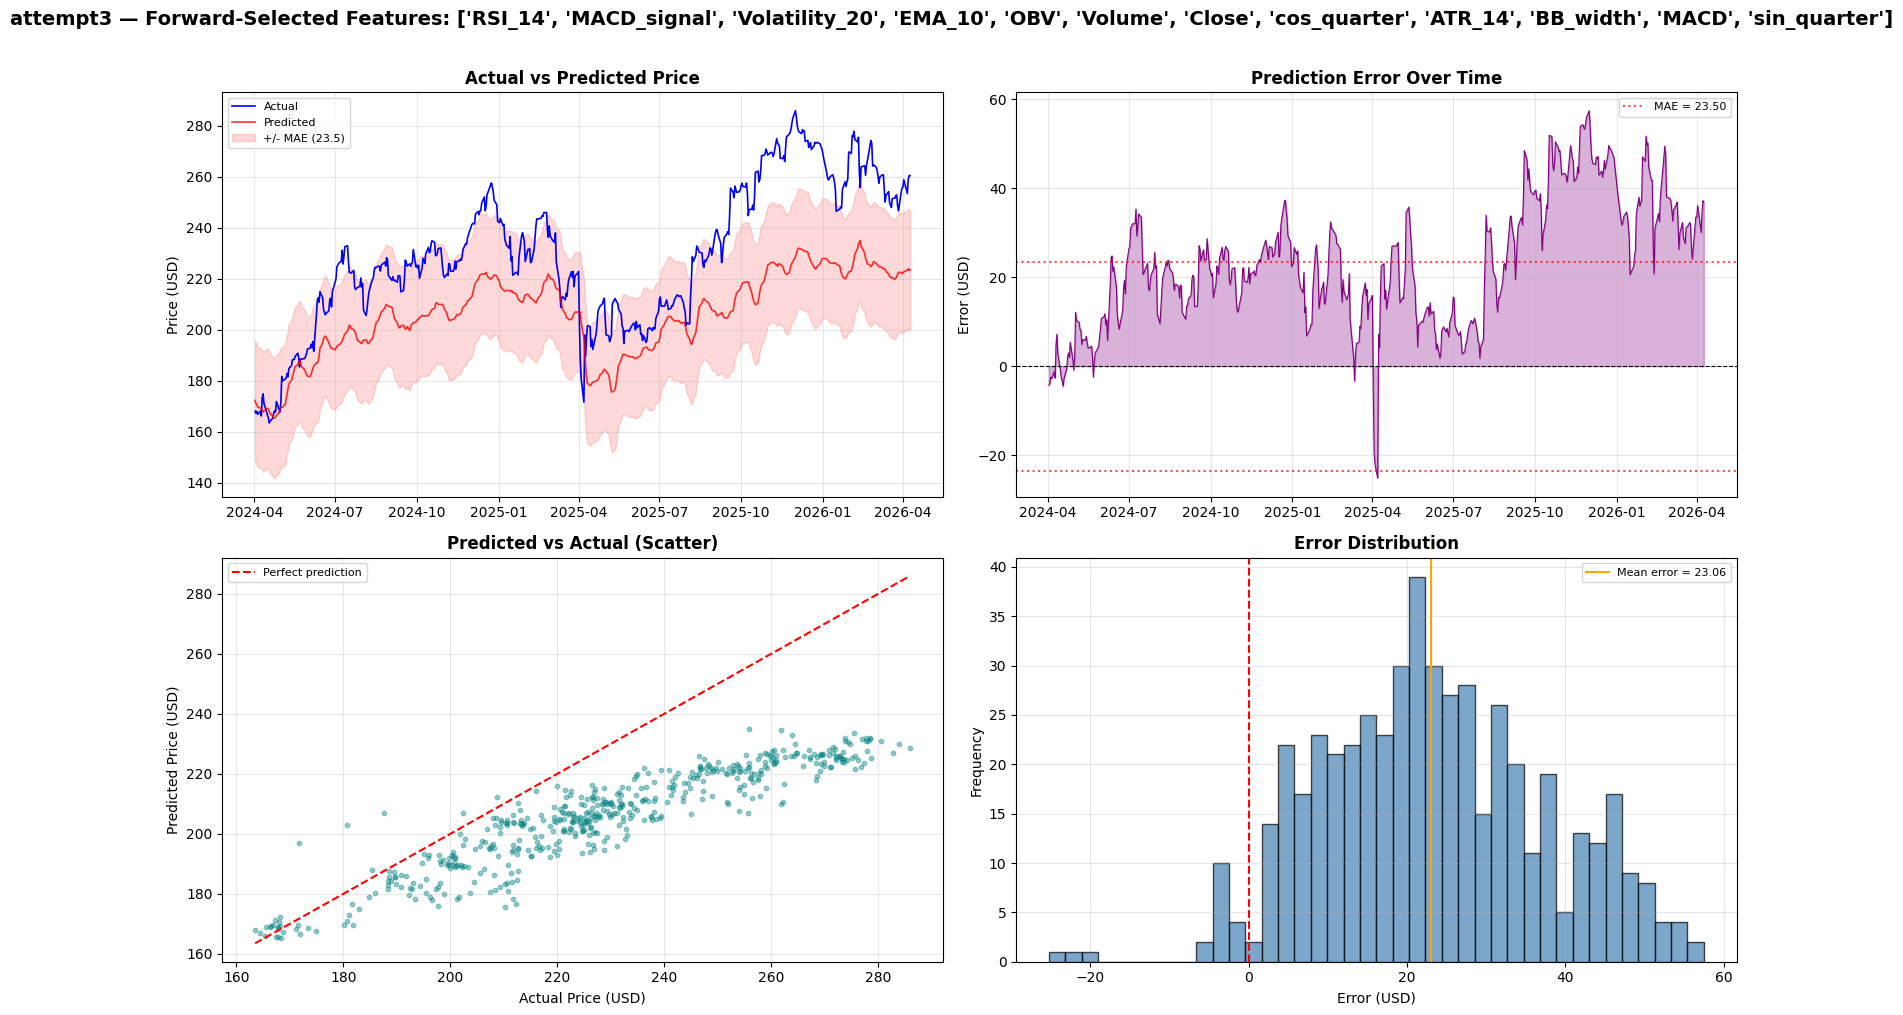

Mean Error: 23.0578  |  Std Error: 14.1486
Max Over-prediction: 57.4735  |  Max Under-prediction: -25.1964
Mean Abs % Error: 9.78%


In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

pred_scaled = model.predict(X_test)
prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))
test_dates = df.index[split_idx:]

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

errors = y_test_actual.flatten() - prediction.flatten()
pct_errors = (errors / y_test_actual.flatten()) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(test_dates, y_test_actual.flatten(), label='Actual', color='blue', linewidth=1.2)
ax.plot(test_dates, prediction.flatten(), label='Predicted', color='red', linewidth=1.2, alpha=0.8)
ax.fill_between(test_dates, prediction.flatten() - mae, prediction.flatten() + mae,
                alpha=0.15, color='red', label=f'+/- MAE ({mae:.1f})')
ax.set_title('Actual vs Predicted Price', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(test_dates, errors, color='purple', linewidth=0.8)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.axhline(y=mae, color='red', linestyle=':', alpha=0.7, label=f'MAE = {mae:.2f}')
ax.axhline(y=-mae, color='red', linestyle=':', alpha=0.7)
ax.fill_between(test_dates, errors, 0, alpha=0.3, color='purple')
ax.set_title('Prediction Error Over Time', fontweight='bold')
ax.set_ylabel('Error (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(y_test_actual.flatten(), prediction.flatten(), alpha=0.4, s=10, color='teal')
min_val = min(y_test_actual.min(), prediction.min())
max_val = max(y_test_actual.max(), prediction.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (USD)')
ax.set_ylabel('Predicted Price (USD)')
ax.set_title('Predicted vs Actual (Scatter)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.hist(errors, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(x=errors.mean(), color='orange', linestyle='-', linewidth=1.5,
           label=f'Mean error = {errors.mean():.2f}')
ax.set_xlabel('Error (USD)')
ax.set_ylabel('Frequency')
ax.set_title('Error Distribution', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle(f'attempt3 — Forward-Selected Features: {feature_cols}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Mean Error: {errors.mean():.4f}  |  Std Error: {errors.std():.4f}')
print(f'Max Over-prediction: {errors.max():.4f}  |  Max Under-prediction: {errors.min():.4f}')
print(f'Mean Abs % Error: {np.abs(pct_errors).mean():.2f}%')